# Wykrywanie Anomalii w Szeregach Czasowych
## NASA SMAP/MSL · Normalizing Flows (RealNVP) · Diffusion Models (DDPM) · LSTM Autoencoder

**Dawid Zawiślak · Jakub Worek**

---

System uczy się wyłącznie na danych normalnych, a następnie ocenia odchylenie każdej nowej próbki od wyuczonego rozkładu.  
Trzy podejścia są porównywane pod kątem **AUC-ROC**, **Precision**, **Recall** i **F1**.

In [1]:
import os
import io
import zipfile
import requests
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import optuna
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (
    roc_auc_score, precision_recall_fscore_support,
    roc_curve
)
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)
optuna.logging.set_verbosity(optuna.logging.WARNING)

CUDA_AVAILABLE = torch.cuda.is_available()
DEVICE = 'cuda' if CUDA_AVAILABLE else 'cpu'
print(f'Urządzenie: {DEVICE}')
print(f'PyTorch: {torch.__version__}')
if CUDA_AVAILABLE:
    print(f'CUDA: {torch.version.cuda}')
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print('CUDA niedostępna. Zainstaluj build CUDA, np.:')
    print('uv pip install --index-url https://download.pytorch.org/whl/cu128 torch==2.7.1+cu128')

Urządzenie: cuda
PyTorch: 2.7.1+cu128
CUDA: 12.8
GPU: NVIDIA GeForce RTX 5070 Laptop GPU


In [2]:
# ── Konfiguracja ──────────────────────────────────────────────────────────────
WINDOW_SIZE   = 100     # długość okna przesuwnego
TRAIN_STRIDE  = 2       # ↓ z 5→2: więcej okien treningowych
BATCH_SIZE    = 256     # bazowy batch dla LSTM / ewaluacji multi-channel
EPOCHS_LSTM   = 80      # ↑ z 40
EPOCHS_FLOW   = 60      # ↑ z 40
EPOCHS_DIFF   = 100     # ↑ z 40
LR            = 3e-4    # bazowy LR dla multi-channel i DDPM
HIDDEN_DIM    = 128     # bazowy LSTM hidden size dla multi-channel
THRESHOLD_PCT = 95      # percentyl do wyznaczenia progu

# ── Optuna / parametry dla kanału głównego ────────────────────────────────────
MAIN_LSTM_HIDDEN        = 160
MAIN_LSTM_LAYERS        = 2
MAIN_LSTM_DROPOUT       = 0.2313811040057837
MAIN_LSTM_LR            = 1.2863908101989929e-4
MAIN_LSTM_THRESHOLD_PCT = 90.57202515257421
MAIN_LSTM_SCORE_SIGN    = 1.0

MAIN_FLOW_BATCH         = 64
MAIN_FLOW_N_FLOWS       = 6
MAIN_FLOW_HIDDEN        = 128
MAIN_FLOW_LR            = 1.2184186502221769e-4
MAIN_FLOW_THRESHOLD_PCT = 97.49198376720379
MAIN_FLOW_SCORE_SIGN    = -1.0

MAIN_DIFF_SCORE_SIGN    = -1.0
MAIN_DIFF_THRESHOLD_PCT = 95.0

# ── Ścieżki ───────────────────────────────────────────────────────────────────
DATA_DIR = './data'

import pathlib as _pl
_candidates = [_pl.Path('./labeled_anomalies.csv'),
               _pl.Path(DATA_DIR) / 'labeled_anomalies.csv']
LABELS_PATH = next((str(p) for p in _candidates if p.exists()), None)

if LABELS_PATH is None:
    raise FileNotFoundError(
        'Nie znaleziono labeled_anomalies.csv.\n'
        'Pobierz plik z:\n'
        '  https://raw.githubusercontent.com/khundman/telemanom'
        '/master/labeled_anomalies.csv\n'
        f'i umieść obok notebooka lub w {DATA_DIR}/'
    )

print(f'DATA_DIR    : {_pl.Path(DATA_DIR).resolve()}')
print(f'LABELS_PATH : {_pl.Path(LABELS_PATH).resolve()}')

# Kanały SMAP/MSL do ewaluacji
CHANNELS     = ['P-1', 'S-1', 'M-6', 'M-1']
MAIN_CHANNEL = 'P-1'   # kanał do szczegółowej wizualizacji


DATA_DIR    : D:\Studies\iwisum\sequential_anomaly_detection\data
LABELS_PATH : D:\Studies\iwisum\sequential_anomaly_detection\labeled_anomalies.csv


## 1. Dane — NASA SMAP / MSL

Zbiór telemetryczny NASA zawierający dane z satelity SMAP i łazika MSL.  
Każdy *kanał* to wielowymiarowy szereg czasowy z ręcznie oznaczonymi anomaliami.

- **train/** — dane normalne (do uczenia modeli)
- **test/**  — dane z anomaliami (do ewaluacji)
- `labeled_anomalies.csv` — zakresy anomalii dla każdego kanału

In [3]:
def load_channel(channel: str, data_dir: str = DATA_DIR):
    train = np.load(os.path.join(data_dir, 'train', f'{channel}.npy'))
    test  = np.load(os.path.join(data_dir, 'test',  f'{channel}.npy'))
    return train.astype(np.float32), test.astype(np.float32)


def build_labels(channel: str, test_len: int,
                 labels_path: str = None) -> np.ndarray:
    path = labels_path or LABELS_PATH
    df   = pd.read_csv(path)
    row  = df[df['chan_id'] == channel]
    lbl  = np.zeros(test_len, dtype=np.int32)
    for _, r in row.iterrows():
        for start, end in eval(r['anomaly_sequences']):
            lbl[start : end + 1] = 1
    return lbl


channel_data: dict = {}
for ch in CHANNELS:
    try:
        tr, te = load_channel(ch)
        lbl    = build_labels(ch, len(te))
        channel_data[ch] = {'train': tr, 'test': te, 'labels': lbl}
        pct = lbl.mean() * 100
        print(f'{ch:6s}  train={tr.shape}  test={te.shape}  '
              f'features={tr.shape[1]}  anomalie={pct:.1f}%')
    except FileNotFoundError as e:
        print(f'{ch}: brak pliku — {e}')


P-1     train=(2872, 25)  test=(8505, 25)  features=25  anomalie=8.8%
S-1     train=(2818, 25)  test=(7331, 25)  features=25  anomalie=6.1%
M-6     train=(1565, 55)  test=(2049, 55)  features=55  anomalie=8.8%
M-1     train=(2209, 55)  test=(2277, 55)  features=55  anomalie=50.1%


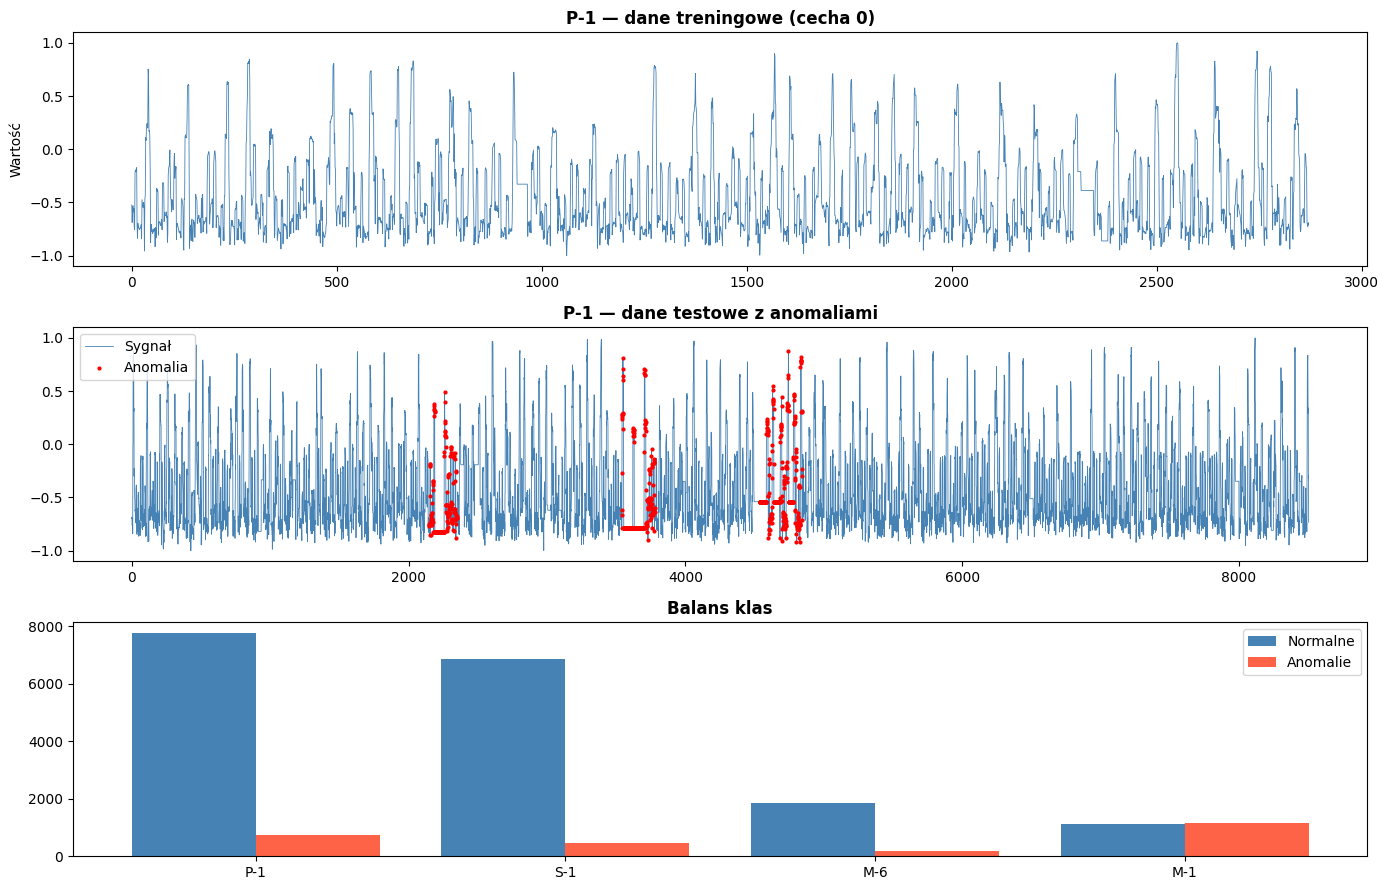

In [4]:
ch  = MAIN_CHANNEL
tr  = channel_data[ch]['train']
te  = channel_data[ch]['test']
lbl = channel_data[ch]['labels']

fig, axes = plt.subplots(3, 1, figsize=(14, 9))

axes[0].plot(tr[:, 0], color='steelblue', lw=0.6)
axes[0].set_title(f'{ch} — dane treningowe (cecha 0)', fontweight='bold')
axes[0].set_ylabel('Wartość')

axes[1].plot(te[:, 0], color='steelblue', lw=0.6, label='Sygnał')
anom_idx = np.where(lbl == 1)[0]
if len(anom_idx):
    axes[1].scatter(anom_idx, te[anom_idx, 0], color='red', s=4,
                    label='Anomalia', zorder=3)
axes[1].set_title(f'{ch} — dane testowe z anomaliami', fontweight='bold')
axes[1].legend()

chs_ok = [c for c in CHANNELS if c in channel_data]
x = np.arange(len(chs_ok))
norm_c = [len(channel_data[c]['labels']) - channel_data[c]['labels'].sum() for c in chs_ok]
anom_c = [channel_data[c]['labels'].sum() for c in chs_ok]
axes[2].bar(x - 0.2, norm_c, 0.4, label='Normalne',  color='steelblue')
axes[2].bar(x + 0.2, anom_c, 0.4, label='Anomalie', color='tomato')
axes[2].set_xticks(x); axes[2].set_xticklabels(chs_ok)
axes[2].set_title('Balans klas', fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.show()

## 2. Preprocessing

1. **StandardScaler** — normalizacja cech (fit na danych treningowych, transform na testowych)
2. **Sliding window** — tworzymy okna o długości `WINDOW_SIZE`  
   - Trening: krok `TRAIN_STRIDE` (szybszy trening, mniej pokrywających się próbek)
   - Test: krok 1 (każdy punkt dostaje swój score)
3. **Etykiety okien** — okno = anomalne, jeśli ≥ 1 punkt w nim jest anomalny

In [5]:
def make_windows(data: np.ndarray, ws: int, stride: int) -> np.ndarray:
    return np.stack([
        data[i : i + ws]
        for i in range(0, len(data) - ws + 1, stride)
    ]).astype(np.float32)


def window_labels(labels: np.ndarray, ws: int) -> np.ndarray:
    return np.array(
        [int(labels[i : i + ws].any()) for i in range(len(labels) - ws + 1)],
        dtype=np.int32
    )


def preprocess(train: np.ndarray, test: np.ndarray, ws: int = WINDOW_SIZE,
               stride: int = TRAIN_STRIDE):
    scaler = StandardScaler()
    tr_norm = scaler.fit_transform(train)
    te_norm = scaler.transform(test)
    return make_windows(tr_norm, ws, stride), make_windows(te_norm, ws, 1), scaler


X_train, X_test, scaler = preprocess(
    channel_data[MAIN_CHANNEL]['train'],
    channel_data[MAIN_CHANNEL]['test']
)
y_test = window_labels(channel_data[MAIN_CHANNEL]['labels'], WINDOW_SIZE)

INPUT_DIM = X_train.shape[2]
FLAT_DIM  = WINDOW_SIZE * INPUT_DIM

print(f'X_train : {X_train.shape}  (okna × czas × cechy)')
print(f'X_test  : {X_test.shape}')
print(f'y_test  : {y_test.shape}   anomalie={y_test.sum()} ({100*y_test.mean():.1f}%)')
print(f'INPUT_DIM={INPUT_DIM}  FLAT_DIM={FLAT_DIM}')

train_tensor = torch.FloatTensor(X_train)
test_tensor  = torch.FloatTensor(X_test)
train_loader = DataLoader(TensorDataset(train_tensor), batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
test_loader  = DataLoader(TensorDataset(test_tensor),  batch_size=BATCH_SIZE, shuffle=False)

X_train : (1387, 100, 25)  (okna × czas × cechy)
X_test  : (8406, 100, 25)
y_test  : (8406,)   anomalie=1048 (12.5%)
INPUT_DIM=25  FLAT_DIM=2500


## 3. Model 1 — LSTM Autoencoder

Sekwencyjny autoencoder oparty na LSTM:
- **Encoder**: LSTM redukuje sekwencję do wektora ukrytego `h`
- **Decoder**: LSTM rekonstruuje sekwencję z `h` (powielany na każdy krok)
- **Anomaly score**: `MSE(x, x̂)` uśrednione po czasie i cechach

Model uczy się na danych normalnych → anomalie mają wyższy błąd rekonstrukcji.

In [6]:
class LSTMAutoencoder(nn.Module):
    """
    LSTM Autoencoder z teacher-forcing w dekoderze.

    Enkoder kompresuje sekwencję do wektora ukrytego h.
    Dekoder dostaje:  [zero_token, x[0], ..., x[T-2]]  (shifted input)
    i przewiduje:     [x[0], ..., x[T-1]]
    Dzięki temu model uczy się lokalnych zależności czasowych,
    a nie tylko globalnego "uśrednienia" sekwencji.
    """
    def __init__(self, input_dim: int, hidden_dim: int = 128,
                 num_layers: int = 2, dropout: float = 0.2):
        super().__init__()
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim
        dp = dropout if num_layers > 1 else 0.0

        self.encoder  = nn.LSTM(input_dim, hidden_dim, num_layers,
                                batch_first=True, dropout=dp)
        # Projekcja stanów ukrytych enkodera na inicjalizację dekodera
        self.h_proj   = nn.Linear(hidden_dim, hidden_dim)
        self.c_proj   = nn.Linear(hidden_dim, hidden_dim)

        self.decoder  = nn.LSTM(input_dim, hidden_dim, num_layers,
                                batch_first=True, dropout=dp)
        self.out_proj = nn.Linear(hidden_dim, input_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, F = x.shape

        # Enkoder
        _, (h_enc, c_enc) = self.encoder(x)

        # Inicjalizacja dekodera z projekcją stanu enkodera
        h_dec = self.h_proj(h_enc)   # (num_layers, B, H)
        c_dec = self.c_proj(c_enc)

        # Teacher forcing: shifted input  [0, x[0], …, x[T-2]]
        pad    = torch.zeros(B, 1, F, device=x.device)
        dec_in = torch.cat([pad, x[:, :-1, :]], dim=1)   # (B, T, F)

        out, _ = self.decoder(dec_in, (h_dec, c_dec))
        return self.out_proj(out)                          # (B, T, F)

    def anomaly_score(self, x: torch.Tensor) -> torch.Tensor:
        return torch.mean((x - self.forward(x)) ** 2, dim=(1, 2))



def train_lstm(model: nn.Module, loader: DataLoader, epochs: int,
               lr: float = LR, tag: str = '') -> list:
    opt  = optim.Adam(model.parameters(), lr=lr)
    sch  = optim.lr_scheduler.CosineAnnealingLR(opt, epochs)
    crit = nn.MSELoss()
    model.train()
    losses = []
    for ep in range(1, epochs + 1):
        running = 0.0
        for (batch,) in loader:
            batch = batch.to(DEVICE)
            opt.zero_grad()
            loss = crit(model(batch), batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            running += loss.item()
        sch.step()
        avg = running / len(loader)
        losses.append(avg)
        if ep % 10 == 0:
            print(f'  [{tag}] ep {ep:3d}/{epochs}  loss={avg:.6f}')
    return losses

  [LSTM] ep  10/80  loss=0.612428
  [LSTM] ep  20/80  loss=0.556815
  [LSTM] ep  30/80  loss=0.523556
  [LSTM] ep  40/80  loss=0.501500
  [LSTM] ep  50/80  loss=0.488819
  [LSTM] ep  60/80  loss=0.482884
  [LSTM] ep  70/80  loss=0.483928
  [LSTM] ep  80/80  loss=0.483933


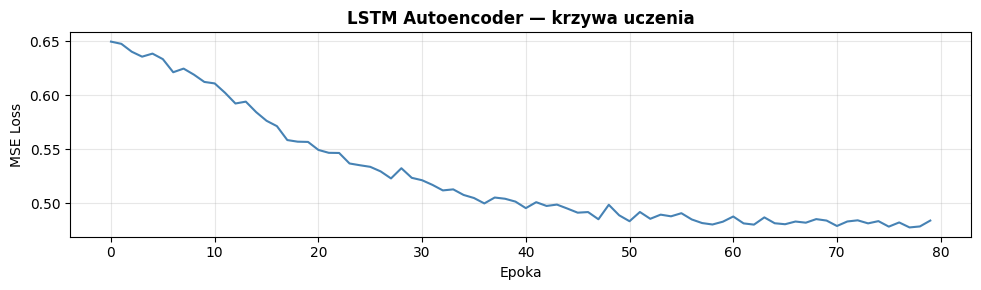

LSTM scores — min=0.021480  mean=0.518087  max=3.043661


In [8]:
@torch.no_grad()
def score_loader(model: nn.Module, loader: DataLoader,
                 score_fn) -> np.ndarray:
    model.eval()
    out = []
    for (batch,) in loader:
        out.append(score_fn(batch.to(DEVICE)).detach().cpu().numpy())
    return np.concatenate(out)


lstm_model = LSTMAutoencoder(
    INPUT_DIM,
    hidden_dim=MAIN_LSTM_HIDDEN,
    num_layers=MAIN_LSTM_LAYERS,
    dropout=MAIN_LSTM_DROPOUT,
).to(DEVICE)

lstm_losses = train_lstm(lstm_model, train_loader, EPOCHS_LSTM, lr=MAIN_LSTM_LR, tag='LSTM')

lstm_scores = score_loader(lstm_model, test_loader, lstm_model.anomaly_score)

plt.figure(figsize=(10, 3))
plt.plot(lstm_losses, color='steelblue')
plt.title('LSTM Autoencoder — krzywa uczenia', fontweight='bold')
plt.xlabel('Epoka'); plt.ylabel('MSE Loss'); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f'LSTM scores — min={lstm_scores.min():.6f}  '
      f'mean={lstm_scores.mean():.6f}  max={lstm_scores.max():.6f}')

## 4. Model 2 — Normalizing Flows (RealNVP)

RealNVP to przepływ normalizujący oparty na warstwach **affine coupling**:
- Wejście (spłaszczone okno) przepuszczamy przez `n_flows` warstw
- Każda warstwa dzieli cechy na dwa podzbiory i transformuje jeden przy użyciu skalowalnej funkcji `s` i translacji `t` drugiego
- Transformacja jest odwracalna, a jakobian jest łatwy do obliczenia
- **Anomaly score**: ujemna log-likelihood `−log p(x)`

Dane normalne mają wysokie `p(x)`, anomalie niskie.

In [9]:
class AffineCoupling(nn.Module):
    """
    Warstwa coupling z:
    - clamping s ∈ [-3, 3]  → zapobiega exp-overflow (scores do 31M)
    - zerową inicjalizacją ostatniej warstwy s_net → stabilny start
    """
    def __init__(self, dim: int, mask: torch.Tensor, hidden: int = 256):
        super().__init__()
        self.register_buffer('mask', mask)

        def mlp(out_act=None):
            layers: list = [
                nn.Linear(dim, hidden), nn.LeakyReLU(0.2),
                nn.Linear(hidden, hidden), nn.LeakyReLU(0.2),
                nn.Linear(hidden, dim),
            ]
            if out_act:
                layers.append(out_act)
            return nn.Sequential(*layers)

        self.s_net = mlp(nn.Tanh())
        self.t_net = mlp()
        # Zero-init: s≈0 na starcie → transformacja ≈ tożsamości
        nn.init.zeros_(self.s_net[-2].weight)
        nn.init.zeros_(self.s_net[-2].bias)

    def forward(self, x: torch.Tensor):
        xm   = x * self.mask
        s    = self.s_net(xm) * (1 - self.mask)
        s    = torch.clamp(s, -3.0, 3.0)      # ← kluczowy fix: brak overflow
        t    = self.t_net(xm) * (1 - self.mask)
        z    = xm + (1 - self.mask) * (x * torch.exp(s) + t)
        ldet = (s * (1 - self.mask)).sum(dim=1)
        return z, ldet

    def inverse(self, z: torch.Tensor) -> torch.Tensor:
        zm = z * self.mask
        s  = torch.clamp(self.s_net(zm) * (1 - self.mask), -3.0, 3.0)
        t  = self.t_net(zm) * (1 - self.mask)
        return zm + (1 - self.mask) * ((z - t) * torch.exp(-s))


class RealNVP(nn.Module):
    def __init__(self, dim: int, n_flows: int = 8, hidden: int = 256):
        super().__init__()
        self.dim = dim
        masks = []
        for i in range(n_flows):
            m = torch.zeros(dim)
            m[:dim // 2] = float(i % 2 == 0)
            m[dim // 2:] = float(i % 2 == 1)
            masks.append(m)
        self.flows = nn.ModuleList(
            [AffineCoupling(dim, m, hidden) for m in masks]
        )

    def log_prob(self, x: torch.Tensor) -> torch.Tensor:
        z, ldet = x, torch.zeros(x.size(0), device=x.device)
        for flow in self.flows:
            z, ld = flow(z)
            ldet  = ldet + ld
        log_pz = -0.5 * (z ** 2 + np.log(2 * np.pi)).sum(dim=1)
        return log_pz + ldet

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return -self.log_prob(x)

    def anomaly_score(self, x: torch.Tensor) -> torch.Tensor:
        return -self.log_prob(x)



def train_flow(model: nn.Module, loader: DataLoader, epochs: int,
               lr: float = LR, tag: str = '') -> list:
    opt = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    sch = optim.lr_scheduler.CosineAnnealingLR(opt, epochs)
    model.train()
    losses = []
    for ep in range(1, epochs + 1):
        running = 0.0
        for (batch,) in loader:
            flat = batch.to(DEVICE).view(batch.size(0), -1)
            opt.zero_grad()
            loss = model(flat).mean()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            running += loss.item()
        sch.step()
        avg = running / len(loader)
        losses.append(avg)
        if ep % 10 == 0:
            print(f'  [{tag}] ep {ep:3d}/{epochs}  NLL={avg:.4f}')
    return losses

In [10]:
# Optuna search for the main channel
OPTUNA_LSTM_TRIALS = 8
OPTUNA_FLOW_TRIALS = 8
OPTUNA_TUNE_EPOCHS = 8
OPTUNA_VAL_FRAC = 0.15
OPTUNA_BATCH_CHOICES = [64, 128, 256]
RUN_OPTUNA = True


def split_train_val(x: np.ndarray, val_frac: float = OPTUNA_VAL_FRAC):
    split = max(1, int(len(x) * (1 - val_frac)))
    if split >= len(x):
        split = max(1, len(x) - 1)
    return x[:split], x[split:]


def make_loader(array: np.ndarray, batch_size: int, shuffle: bool = False, drop_last: bool = False):
    tensor = torch.as_tensor(array, dtype=torch.float32)
    return DataLoader(TensorDataset(tensor), batch_size=batch_size, shuffle=shuffle, drop_last=drop_last)


@torch.no_grad()
def eval_lstm_loss(model: nn.Module, loader: DataLoader) -> float:
    model.eval()
    losses = []
    for (batch,) in loader:
        batch = batch.to(DEVICE)
        losses.append(nn.functional.mse_loss(model(batch), batch).item())
    return float(np.mean(losses))


@torch.no_grad()
def eval_flow_loss(model: nn.Module, loader: DataLoader) -> float:
    model.eval()
    losses = []
    for (batch,) in loader:
        flat = batch.to(DEVICE).view(batch.size(0), -1)
        losses.append(model(flat).mean().item())
    return float(np.mean(losses))


X_tune_train, X_tune_val = split_train_val(X_train)
print(f'Optuna split: train={X_tune_train.shape}, val={X_tune_val.shape}')

if RUN_OPTUNA and len(X_tune_val) > 0:
    lstm_sampler = optuna.samplers.TPESampler(seed=42)

    def objective_lstm(trial: optuna.Trial) -> float:
        hidden_dim = trial.suggest_categorical('hidden_dim', [64, 96, 128, 160, 192, 256])
        num_layers = trial.suggest_int('num_layers', 1, 3)
        dropout = trial.suggest_float('dropout', 0.0, 0.35)
        lr = trial.suggest_float('lr', 1e-4, 6e-4, log=True)
        batch_size = trial.suggest_categorical('batch_size', OPTUNA_BATCH_CHOICES)

        tr_loader = make_loader(X_tune_train, batch_size=batch_size, shuffle=True, drop_last=False)
        val_loader = make_loader(X_tune_val, batch_size=batch_size, shuffle=False)

        model = LSTMAutoencoder(
            INPUT_DIM,
            hidden_dim=hidden_dim,
            num_layers=num_layers,
            dropout=dropout,
        ).to(DEVICE)
        train_lstm(model, tr_loader, OPTUNA_TUNE_EPOCHS, lr=lr, tag=f'optuna-lstm-{trial.number}')
        return eval_lstm_loss(model, val_loader)

    lstm_study = optuna.create_study(direction='minimize', sampler=lstm_sampler)
    lstm_study.optimize(objective_lstm, n_trials=OPTUNA_LSTM_TRIALS, show_progress_bar=False)
    best_lstm = lstm_study.best_params
    print('Best LSTM params:', best_lstm)
    print(f'Best LSTM val loss: {lstm_study.best_value:.6f}')
else:
    best_lstm = {
        'hidden_dim': MAIN_LSTM_HIDDEN,
        'num_layers': MAIN_LSTM_LAYERS,
        'dropout': MAIN_LSTM_DROPOUT,
        'lr': MAIN_LSTM_LR,
        'batch_size': BATCH_SIZE,
    }
    print('Optuna skipped for LSTM; using fallback parameters.')

MAIN_LSTM_HIDDEN = int(best_lstm['hidden_dim'])
MAIN_LSTM_LAYERS = int(best_lstm['num_layers'])
MAIN_LSTM_DROPOUT = float(best_lstm['dropout'])
MAIN_LSTM_LR = float(best_lstm['lr'])
BATCH_SIZE = int(best_lstm['batch_size'])

train_loader = make_loader(X_train, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
test_loader = make_loader(X_test, batch_size=BATCH_SIZE, shuffle=False)

lstm_model = LSTMAutoencoder(
    INPUT_DIM,
    hidden_dim=MAIN_LSTM_HIDDEN,
    num_layers=MAIN_LSTM_LAYERS,
    dropout=MAIN_LSTM_DROPOUT,
).to(DEVICE)
print(f'LSTM Autoencoder — {sum(p.numel() for p in lstm_model.parameters()):,} parametrów')
lstm_losses = train_lstm(lstm_model, train_loader, EPOCHS_LSTM, lr=MAIN_LSTM_LR, tag='LSTM')

if RUN_OPTUNA and len(X_tune_val) > 0:
    flow_sampler = optuna.samplers.TPESampler(seed=42)

    def objective_flow(trial: optuna.Trial) -> float:
        n_flows = trial.suggest_int('n_flows', 4, 8)
        hidden = trial.suggest_categorical('hidden', [64, 96, 128, 160, 192, 256])
        lr = trial.suggest_float('lr', 1e-4, 6e-4, log=True)
        batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])

        tr_loader = make_loader(X_tune_train, batch_size=batch_size, shuffle=True, drop_last=False)
        val_loader = make_loader(X_tune_val, batch_size=batch_size, shuffle=False)

        model = RealNVP(FLAT_DIM, n_flows=n_flows, hidden=hidden).to(DEVICE)
        train_flow(model, tr_loader, OPTUNA_TUNE_EPOCHS, lr=lr, tag=f'optuna-flow-{trial.number}')
        return eval_flow_loss(model, val_loader)

    flow_study = optuna.create_study(direction='minimize', sampler=flow_sampler)
    flow_study.optimize(objective_flow, n_trials=OPTUNA_FLOW_TRIALS, show_progress_bar=False)
    best_flow = flow_study.best_params
    print('Best RealNVP params:', best_flow)
    print(f'Best RealNVP val loss: {flow_study.best_value:.6f}')
else:
    best_flow = {
        'n_flows': MAIN_FLOW_N_FLOWS,
        'hidden': MAIN_FLOW_HIDDEN,
        'lr': MAIN_FLOW_LR,
        'batch_size': MAIN_FLOW_BATCH,
    }
    print('Optuna skipped for RealNVP; using fallback parameters.')

MAIN_FLOW_N_FLOWS = int(best_flow['n_flows'])
MAIN_FLOW_HIDDEN = int(best_flow['hidden'])
MAIN_FLOW_LR = float(best_flow['lr'])
MAIN_FLOW_BATCH = int(best_flow['batch_size'])

flow_train_loader = make_loader(X_train, batch_size=MAIN_FLOW_BATCH, shuffle=True, drop_last=True)
flow_test_loader = make_loader(X_test, batch_size=MAIN_FLOW_BATCH, shuffle=False)

flow_model = RealNVP(FLAT_DIM, n_flows=MAIN_FLOW_N_FLOWS, hidden=MAIN_FLOW_HIDDEN).to(DEVICE)
print(f'RealNVP — {sum(p.numel() for p in flow_model.parameters()):,} parametrów')
flow_losses = train_flow(flow_model, flow_train_loader, EPOCHS_FLOW, lr=MAIN_FLOW_LR, tag='RealNVP')

Optuna split: train=(1178, 100, 25), val=(209, 100, 25)
Best LSTM params: {'hidden_dim': 192, 'num_layers': 1, 'dropout': 0.24963567552804825, 'lr': 0.0003908461486722685, 'batch_size': 128}
Best LSTM val loss: 0.927367
LSTM Autoencoder — 415,321 parametrów
  [LSTM] ep  10/80  loss=0.473208
  [LSTM] ep  20/80  loss=0.416819
  [LSTM] ep  30/80  loss=0.378784
  [LSTM] ep  40/80  loss=0.354755
  [LSTM] ep  50/80  loss=0.338183
  [LSTM] ep  60/80  loss=0.331651
  [LSTM] ep  70/80  loss=0.322942
  [LSTM] ep  80/80  loss=0.321923
Best RealNVP params: {'n_flows': 8, 'hidden': 64, 'lr': 0.00012444120419299886, 'batch_size': 128}
Best RealNVP val loss: 4382.602783
RealNVP — 5,227,584 parametrów
  [RealNVP] ep  10/60  NLL=887.2615
  [RealNVP] ep  20/60  NLL=-1445.4150
  [RealNVP] ep  30/60  NLL=-2367.3808
  [RealNVP] ep  40/60  NLL=-2847.5694
  [RealNVP] ep  50/60  NLL=-3037.7488
  [RealNVP] ep  60/60  NLL=-3073.4763


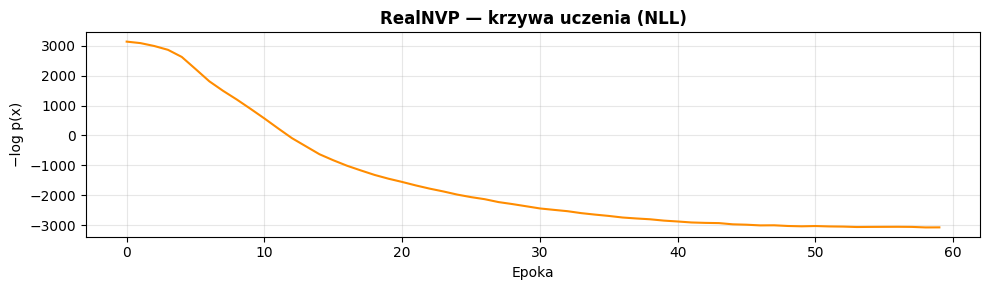

RealNVP scores — min=-4373.81  mean=20063.15  max=2623264.50


In [11]:
@torch.no_grad()
def score_flow_loader(model: nn.Module, loader: DataLoader) -> np.ndarray:
    model.eval()
    out = []
    for (batch,) in loader:
        flat = batch.to(DEVICE).view(batch.size(0), -1)
        out.append(model.anomaly_score(flat).detach().cpu().numpy())
    return np.concatenate(out)


flow_scores = score_flow_loader(flow_model, test_loader)

plt.figure(figsize=(10, 3))
plt.plot(flow_losses, color='darkorange')
plt.title('RealNVP — krzywa uczenia (NLL)', fontweight='bold')
plt.xlabel('Epoka'); plt.ylabel('−log p(x)'); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f'RealNVP scores — min={flow_scores.min():.2f}  '
      f'mean={flow_scores.mean():.2f}  max={flow_scores.max():.2f}')

## 5. Model 3 — Diffusion Model (DDPM)

Denoising Diffusion Probabilistic Model zaadaptowany do szeregów czasowych:

**Proces forward** (dodawanie szumu):  
$q(x_t | x_0) = \mathcal{N}(x_t; \sqrt{\bar{\alpha}_t}\, x_0,\; (1-\bar{\alpha}_t)\mathbf{I})$

**Trening**: sieć $\epsilon_\theta(x_t, t)$ uczy się odgadywać szum $\epsilon$ dodany do $x_0$.

**Anomaly score**: średni błąd predykcji szumu dla kroków z zakresu $[T/4, T/2]$.  
Dane normalne są lepiej „zrozumiane” przez sieć → niższy błąd → niższy score.

Sinusoidalne osadzenie kroku $t$ kondycjonuje sieć denoisingową.

In [12]:
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        half = dim // 2
        freqs = torch.exp(-np.log(10_000) * torch.arange(half).float() / half)
        self.register_buffer('freqs', freqs)
        self.proj = nn.Sequential(
            nn.Linear(dim, dim * 2), nn.SiLU(), nn.Linear(dim * 2, dim)
        )

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        args = t.float().unsqueeze(1) * self.freqs.unsqueeze(0)
        emb  = torch.cat([args.sin(), args.cos()], dim=1)
        return self.proj(emb)


class DenoisingMLP(nn.Module):
    def __init__(self, input_dim: int, hidden: int = 512, time_dim: int = 128):
        super().__init__()
        self.time_emb = SinusoidalTimeEmbedding(time_dim)
        self.net = nn.Sequential(
            nn.Linear(input_dim + time_dim, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden),               nn.SiLU(),
            nn.Linear(hidden, hidden),               nn.SiLU(),
            nn.Linear(hidden, hidden),               nn.SiLU(),
            nn.Linear(hidden, input_dim),
        )

    def forward(self, x_noisy: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        return self.net(torch.cat([x_noisy, self.time_emb(t)], dim=1))


class DDPM(nn.Module):
    def __init__(self, input_dim: int, T: int = 200,
                 hidden: int = 512, time_dim: int = 128):
        super().__init__()
        self.T        = T
        self.denoiser = DenoisingMLP(input_dim, hidden, time_dim)

        betas      = torch.linspace(1e-4, 0.02, T)
        alphas     = 1.0 - betas
        alpha_bars = torch.cumprod(alphas, 0)
        self.register_buffer('betas',      betas)
        self.register_buffer('alphas',     alphas)
        self.register_buffer('alpha_bars', alpha_bars)

    def q_sample(self, x0: torch.Tensor, t: torch.Tensor,
                 noise: torch.Tensor | None = None):
        if noise is None:
            noise = torch.randn_like(x0)
        ab  = self.alpha_bars[t].view(-1, 1)
        x_t = torch.sqrt(ab) * x0 + torch.sqrt(1 - ab) * noise
        return x_t, noise

    def forward(self, x0: torch.Tensor) -> torch.Tensor:
        t    = torch.randint(0, self.T, (x0.size(0),), device=x0.device)
        xt, noise = self.q_sample(x0, t)
        return nn.functional.mse_loss(self.denoiser(xt, t), noise)

    @torch.no_grad()
    def anomaly_score(self, x0: torch.Tensor, n_avg: int = 20) -> torch.Tensor:
        """
        Używamy małych kroków t ∈ [1, T//4] gdzie sygnał jest jeszcze
        czytelny — model musi ROZUMIEĆ dane żeby dobrze odszumić.
        Anomalie: model wytrenowany na normalnych danych → wysoki błąd.
        """
        self.eval()
        scores = torch.zeros(x0.size(0), device=x0.device)
        lo, hi = 1, max(2, self.T // 4)   # ← fix: niskie t, duży SNR
        for _ in range(n_avg):
            t  = torch.randint(lo, hi, (x0.size(0),), device=x0.device)
            xt, noise = self.q_sample(x0, t)
            pred      = self.denoiser(xt, t)
            scores   += ((pred - noise) ** 2).mean(dim=1)
        return scores / n_avg


def train_diffusion(model: nn.Module, loader: DataLoader, epochs: int,
                    lr: float = LR, tag: str = '') -> list:
    opt = optim.AdamW(model.parameters(), lr=lr)
    sch = optim.lr_scheduler.CosineAnnealingLR(opt, epochs)
    model.train()
    losses = []
    for ep in range(1, epochs + 1):
        running = 0.0
        for (batch,) in loader:
            flat = batch.to(DEVICE).view(batch.size(0), -1)
            opt.zero_grad()
            loss = model(flat)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            running += loss.item()
        sch.step()
        avg = running / len(loader)
        losses.append(avg)
        if ep % 10 == 0:
            print(f'  [{tag}] ep {ep:3d}/{epochs}  loss={avg:.6f}')
    return losses


diff_model = DDPM(FLAT_DIM, T=200, hidden=512, time_dim=128).to(DEVICE)
nparams = sum(p.numel() for p in diff_model.parameters())
print(f'DDPM — {nparams:,} parametrów')
diff_losses = train_diffusion(diff_model, train_loader, EPOCHS_DIFF, tag='DDPM')


DDPM — 3,482,436 parametrów
  [DDPM] ep  10/100  loss=0.991867
  [DDPM] ep  20/100  loss=0.976542
  [DDPM] ep  30/100  loss=0.965263
  [DDPM] ep  40/100  loss=0.958224
  [DDPM] ep  50/100  loss=0.952901
  [DDPM] ep  60/100  loss=0.948073
  [DDPM] ep  70/100  loss=0.942535
  [DDPM] ep  80/100  loss=0.940961
  [DDPM] ep  90/100  loss=0.940623
  [DDPM] ep 100/100  loss=0.939351


Obliczanie scorów DDPM (może chwilę potrwać)...


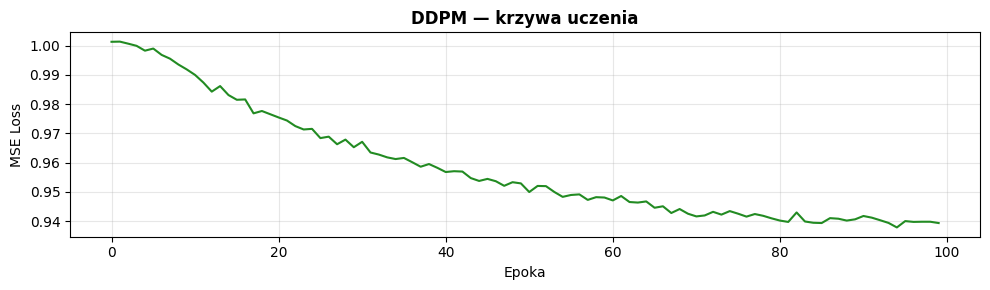

DDPM scores — min=0.945413  mean=0.980681  max=1.245078


In [13]:
@torch.no_grad()
def score_diff_loader(model: nn.Module, loader: DataLoader,
                      n_avg: int = 20) -> np.ndarray:
    model.eval()
    out = []
    for (batch,) in loader:
        flat = batch.to(DEVICE).view(batch.size(0), -1)
        out.append(model.anomaly_score(flat, n_avg).detach().cpu().numpy())
    return np.concatenate(out)


print('Obliczanie scorów DDPM (może chwilę potrwać)...')
diff_scores = score_diff_loader(diff_model, test_loader, n_avg=20)

plt.figure(figsize=(10, 3))
plt.plot(diff_losses, color='forestgreen')
plt.title('DDPM — krzywa uczenia', fontweight='bold')
plt.xlabel('Epoka'); plt.ylabel('MSE Loss'); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f'DDPM scores — min={diff_scores.min():.6f}  '
      f'mean={diff_scores.mean():.6f}  max={diff_scores.max():.6f}')

## 6. Próg decyzyjny i ocena

Próg wyznaczamy jako **percentyl 95** scorów na danych treningowych:  
→ zakładamy, że ≤ 5% próbek treningowych to potencjalne szumy / łagodne odchylenia.

Metryki:
| Metryka | Opis |
|---|---|
| AUC-ROC | Niezależna od progu, mierzy zdolność separacji |
| Precision | Jak wiele alarmów jest prawdziwymi anomaliami |
| Recall | Jak wiele anomalii zostało wykrytych |
| F1 | Harmonia precision i recall |

In [14]:
def compute_threshold(scores: np.ndarray, pct: float = THRESHOLD_PCT) -> float:
    return float(np.percentile(scores, pct))



def point_adjust(scores: np.ndarray, labels: np.ndarray,
                 threshold: float) -> np.ndarray:
    """
    Point-adjust: standardowa metoda dla SMAP/MSL.
    Jeśli model wykryje anomalię w dowolnym punkcie segmentu,
    cały segment jest liczony jako wykryty (TP).
    """
    preds = (scores > threshold).astype(int).copy()
    n = len(labels)
    i = 0
    while i < n:
        if labels[i] == 1:
            j = i
            while j < n and labels[j] == 1:
                j += 1
            if preds[i:j].any():
                preds[i:j] = 1
            i = j
        else:
            i += 1
    return preds



def evaluate(scores: np.ndarray, labels: np.ndarray, threshold: float) -> dict:
    preds    = (scores > threshold).astype(int)
    pa_preds = point_adjust(scores, labels, threshold)

    auc            = roc_auc_score(labels, scores)
    p,  r,  f1,  _ = precision_recall_fscore_support(
        labels, preds,    average='binary', zero_division=0)
    _, _, pa_f1, _ = precision_recall_fscore_support(
        labels, pa_preds, average='binary', zero_division=0)

    return {
        'AUC-ROC':  auc,
        'Precision': p,   'Recall': r,   'F1': f1,
        'PA-F1':    pa_f1,               # point-adjusted F1
        'threshold': threshold,
    }


# ── Progi z danych treningowych ───────────────────────────────────────────────
n_thr     = min(2000, len(train_tensor))
sample_idx = np.random.choice(len(train_tensor), n_thr, replace=False)
tr_sample  = train_tensor[sample_idx].to(DEVICE)

with torch.no_grad():
    lstm_tr = MAIN_LSTM_SCORE_SIGN * lstm_model.anomaly_score(tr_sample).detach().cpu().numpy()
    flow_tr = MAIN_FLOW_SCORE_SIGN * flow_model.anomaly_score(
        tr_sample.view(n_thr, -1)).detach().cpu().numpy()
    diff_tr = MAIN_DIFF_SCORE_SIGN * diff_model.anomaly_score(
        tr_sample.view(n_thr, -1), n_avg=10).detach().cpu().numpy()

lstm_thr = compute_threshold(lstm_tr, MAIN_LSTM_THRESHOLD_PCT)
flow_thr = compute_threshold(flow_tr, MAIN_FLOW_THRESHOLD_PCT)
diff_thr = compute_threshold(diff_tr, MAIN_DIFF_THRESHOLD_PCT)

print('Progi (kanał główny po strojeníu Optuna):')
print(f'  LSTM Autoencoder : {lstm_thr:.6f}')
print(f'  RealNVP          : {flow_thr:.4f}')
print(f'  DDPM             : {diff_thr:.6f}')

# ── Scores: main-channel tuning ───────────────────────────────────────────────
lstm_scores = MAIN_LSTM_SCORE_SIGN * score_loader(lstm_model, test_loader, lstm_model.anomaly_score)
flow_scores = MAIN_FLOW_SCORE_SIGN * score_flow_loader(flow_model, flow_test_loader)
diff_scores = MAIN_DIFF_SCORE_SIGN * score_diff_loader(diff_model, test_loader, n_avg=20)

lstm_metrics = evaluate(lstm_scores,         y_test, lstm_thr)
flow_metrics = evaluate(flow_scores,         y_test, flow_thr)
diff_metrics = evaluate(diff_scores,         y_test, diff_thr)

results = pd.DataFrame({
    'LSTM Autoencoder': lstm_metrics,
    'RealNVP (NF)':     flow_metrics,
    'DDPM (Diffusion)': diff_metrics,
}).T.drop(columns=['threshold'])

print(f'\n══ Wyniki — kanał {MAIN_CHANNEL} ══')
print(results.round(4).to_string())


Progi (kanał główny po strojeníu Optuna):
  LSTM Autoencoder : 0.855110
  RealNVP          : 4131.2979
  DDPM             : -0.952649

══ Wyniki — kanał P-1 ══
                  AUC-ROC  Precision  Recall      F1   PA-F1
LSTM Autoencoder   0.3834     0.0784  0.0954  0.0861  0.3101
RealNVP (NF)       0.5929     0.0846  0.0105  0.0187  0.9463
DDPM (Diffusion)   0.5814     0.2353  0.0115  0.0218  0.7889


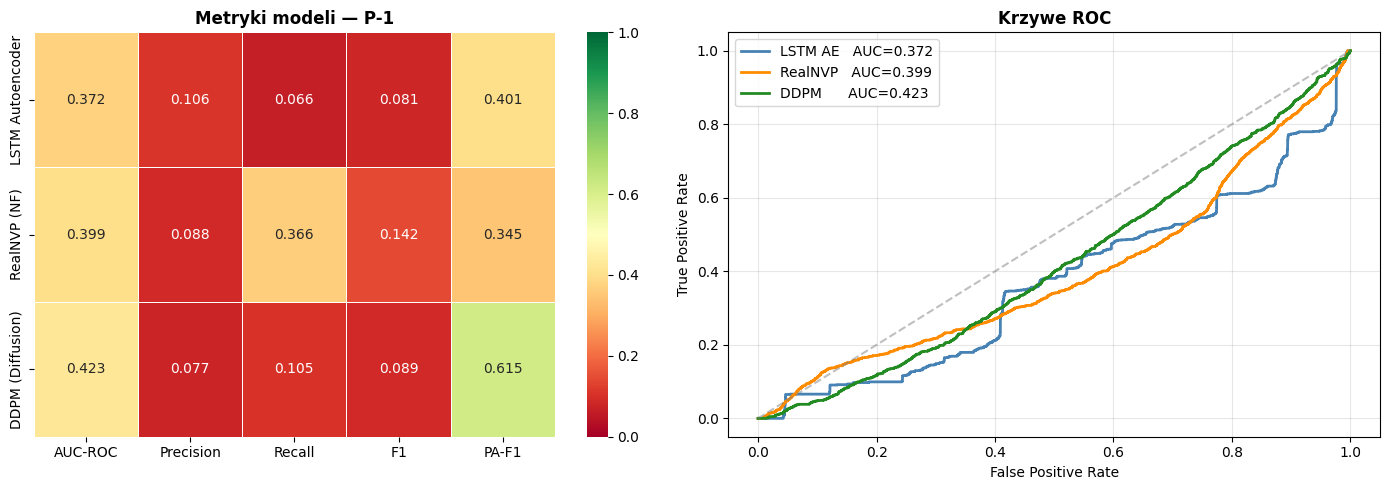

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmapa metryk
sns.heatmap(
    results.astype(float), annot=True, fmt='.3f',
    cmap='RdYlGn', vmin=0, vmax=1,
    linewidths=0.5, ax=axes[0]
)
axes[0].set_title(f'Metryki modeli — {MAIN_CHANNEL}', fontweight='bold')

# Krzywe ROC
fpr_l, tpr_l, _ = roc_curve(y_test, lstm_scores)
fpr_f, tpr_f, _ = roc_curve(y_test, flow_scores)
fpr_d, tpr_d, _ = roc_curve(y_test, diff_scores)

axes[1].plot(fpr_l, tpr_l, lw=2, color='steelblue',
             label=f"LSTM AE   AUC={lstm_metrics['AUC-ROC']:.3f}")
axes[1].plot(fpr_f, tpr_f, lw=2, color='darkorange',
             label=f"RealNVP   AUC={flow_metrics['AUC-ROC']:.3f}")
axes[1].plot(fpr_d, tpr_d, lw=2, color='forestgreen',
             label=f"DDPM      AUC={diff_metrics['AUC-ROC']:.3f}")
axes[1].plot([0, 1], [0, 1], '--', color='grey', alpha=0.5)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Krzywe ROC', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

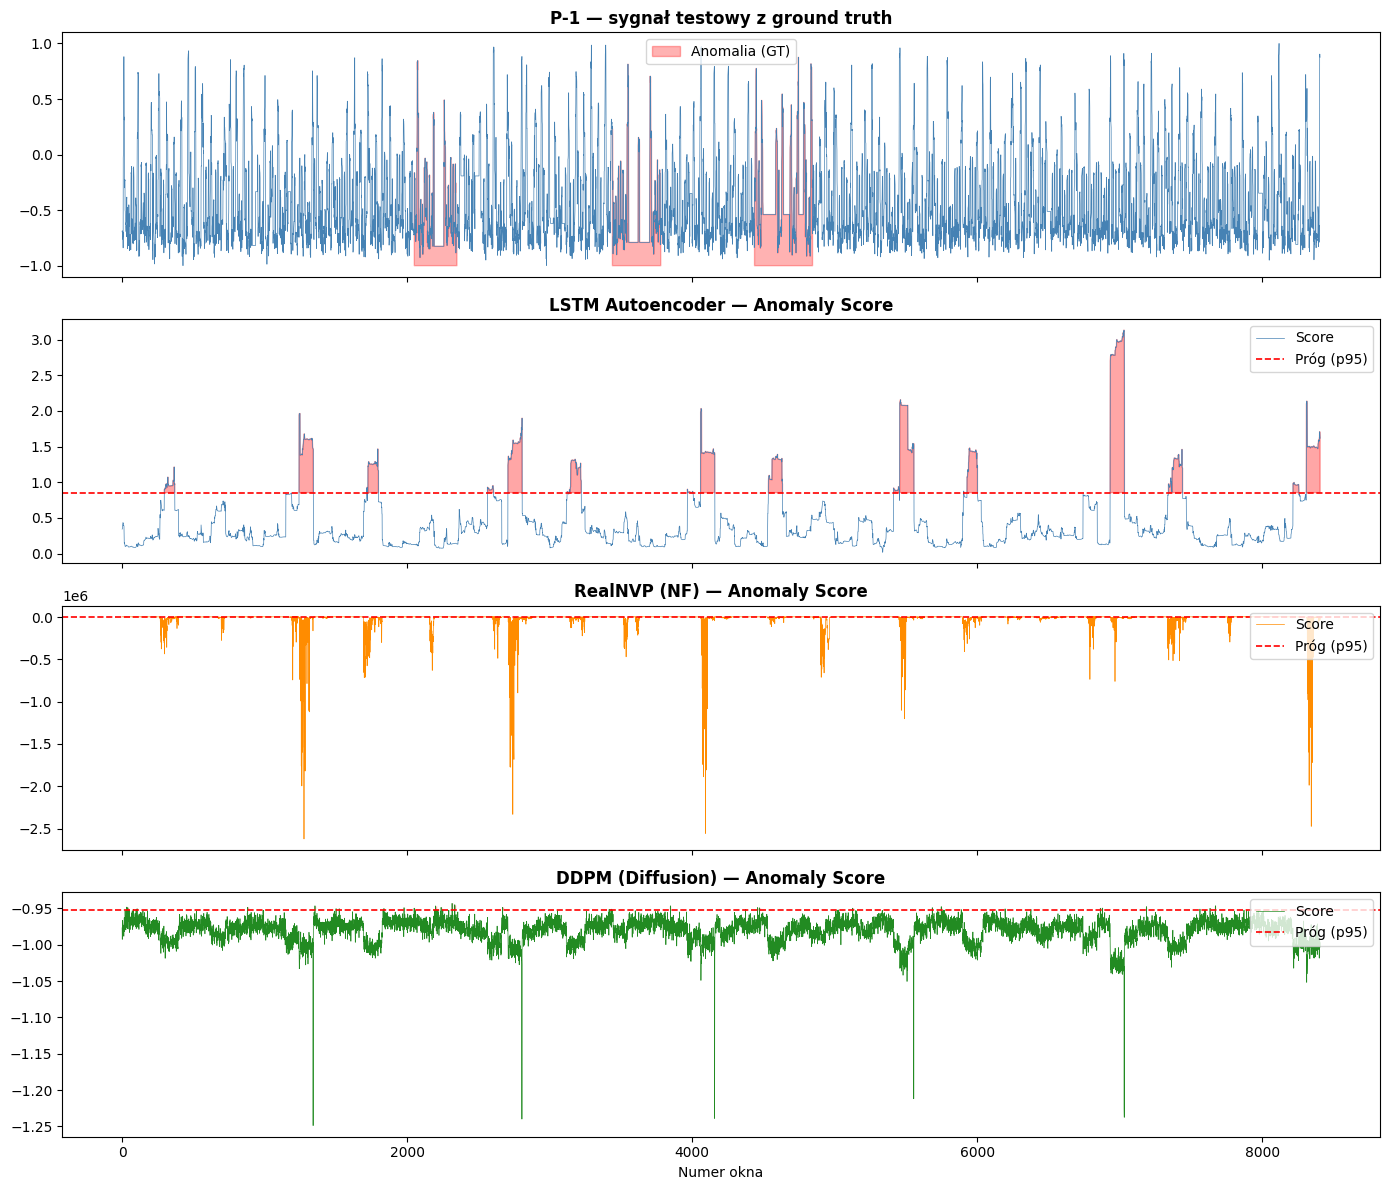

In [15]:
# Anomaly scores w czasie + próg
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

sig = channel_data[MAIN_CHANNEL]['test'][:, 0]
t_axis = np.arange(len(y_test))

axes[0].plot(sig[:len(y_test)], color='steelblue', lw=0.5)
axes[0].fill_between(t_axis, sig.min(), sig[:len(y_test)],
                     where=(y_test == 1), alpha=0.3, color='red',
                     label='Anomalia (GT)')
axes[0].set_title(f'{MAIN_CHANNEL} — sygnał testowy z ground truth', fontweight='bold')
axes[0].legend()

for ax, scores, thr, name, color in [
    (axes[1], lstm_scores, lstm_thr, 'LSTM Autoencoder', 'steelblue'),
    (axes[2], flow_scores, flow_thr, 'RealNVP (NF)',    'darkorange'),
    (axes[3], diff_scores, diff_thr, 'DDPM (Diffusion)','forestgreen'),
]:
    ax.plot(scores, color=color, lw=0.5, label='Score')
    ax.axhline(thr, color='red', ls='--', lw=1.2,
               label=f'Próg (p{THRESHOLD_PCT})')
    ax.fill_between(t_axis, thr, scores,
                    where=(scores > thr), alpha=0.35, color='red')
    ax.set_title(f'{name} — Anomaly Score', fontweight='bold')
    ax.legend(loc='upper right')

axes[3].set_xlabel('Numer okna')
plt.tight_layout()
plt.show()

## 7. Ewaluacja na wielu kanałach

Trenujemy LSTM i RealNVP na każdym kanale (krótszy trening = 20 epok)  
i porównujemy AUC-ROC oraz F1.

In [16]:
def run_channel(channel: str, epochs: int = 20) -> dict | None:
    if channel not in channel_data:
        return None

    Xtr, Xte, _ = preprocess(
        channel_data[channel]['train'],
        channel_data[channel]['test']
    )
    yt = window_labels(channel_data[channel]['labels'], WINDOW_SIZE)

    if yt.sum() == 0:
        print(f'  {channel}: brak anomalii — pomijam')
        return None

    idim  = Xtr.shape[2]
    fdim  = WINDOW_SIZE * idim
    tr_t  = torch.FloatTensor(Xtr)
    te_t  = torch.FloatTensor(Xte)
    tr_ld = DataLoader(TensorDataset(tr_t), batch_size=BATCH_SIZE,
                       shuffle=True, drop_last=True)
    te_ld = DataLoader(TensorDataset(te_t), batch_size=BATCH_SIZE)

    n_thr = min(1000, len(tr_t))
    idx   = np.random.choice(len(tr_t), n_thr, replace=False)

    # LSTM
    m_lstm = LSTMAutoencoder(idim, HIDDEN_DIM).to(DEVICE)
    train_lstm(m_lstm, tr_ld, epochs, tag=f'{channel}/LSTM')
    with torch.no_grad():
        tr_s = m_lstm.anomaly_score(tr_t[idx].to(DEVICE)).detach().cpu().numpy()
    te_s     = score_loader(m_lstm, te_ld, m_lstm.anomaly_score)
    lstm_m   = evaluate(te_s, yt, compute_threshold(tr_s))

    # RealNVP
    m_flow = RealNVP(fdim, n_flows=6, hidden=128).to(DEVICE)
    train_flow(m_flow, tr_ld, epochs, tag=f'{channel}/NF')
    with torch.no_grad():
        ftr_s = m_flow.anomaly_score(
            tr_t[idx].to(DEVICE).view(n_thr, -1)).detach().cpu().numpy()
    fte_s   = score_flow_loader(m_flow, te_ld)
    flow_m  = evaluate(fte_s, yt, compute_threshold(ftr_s))

    return {
        'LSTM  AUC': lstm_m['AUC-ROC'],
        'LSTM  F1':  lstm_m['F1'],
        'NF    AUC': flow_m['AUC-ROC'],
        'NF    F1':  flow_m['F1'],
    }


all_results: dict = {}
for ch in CHANNELS:
    print(f'\n── Kanał: {ch} ──')
    res = run_channel(ch, epochs=20)
    if res:
        all_results[ch] = res

if all_results:
    df_all = pd.DataFrame(all_results).T
    print('\n══ Podsumowanie wszystkich kanałów ══')
    print(df_all.round(4).to_string())


── Kanał: P-1 ──
  [P-1/LSTM] ep  10/20  loss=0.525817
  [P-1/LSTM] ep  20/20  loss=0.496979
  [P-1/NF] ep  10/20  NLL=-1165.3358
  [P-1/NF] ep  20/20  NLL=-1986.0770

── Kanał: S-1 ──
  [S-1/LSTM] ep  10/20  loss=0.548660
  [S-1/LSTM] ep  20/20  loss=0.518846
  [S-1/NF] ep  10/20  NLL=-1118.0467
  [S-1/NF] ep  20/20  NLL=-1788.3048

── Kanał: M-6 ──
  [M-6/LSTM] ep  10/20  loss=0.199610
  [M-6/LSTM] ep  20/20  loss=0.197454
  [M-6/NF] ep  10/20  NLL=-5218.3677
  [M-6/NF] ep  20/20  NLL=-6049.0047

── Kanał: M-1 ──
  [M-1/LSTM] ep  10/20  loss=0.218026
  [M-1/LSTM] ep  20/20  loss=0.216053
  [M-1/NF] ep  10/20  NLL=-7116.5799
  [M-1/NF] ep  20/20  NLL=-7725.7712

══ Podsumowanie wszystkich kanałów ══
     LSTM  AUC  LSTM  F1  NF    AUC  NF    F1
P-1     0.3600    0.0875     0.3985    0.1322
S-1     0.3421    0.0000     0.3400    0.0791
M-6     0.9871    0.3864     0.9845    0.2466
M-1     0.5698    0.0615     0.5323    0.3434


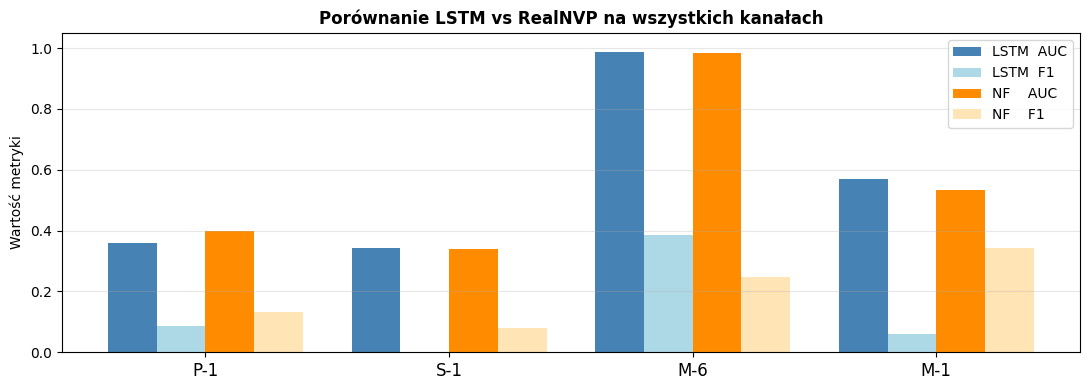

In [17]:
if all_results:
    fig, ax = plt.subplots(figsize=(11, 4))
    x  = np.arange(len(df_all))
    w  = 0.2
    ax.bar(x - 1.5*w, df_all['LSTM  AUC'], w, label='LSTM  AUC', color='steelblue')
    ax.bar(x - 0.5*w, df_all['LSTM  F1'],  w, label='LSTM  F1',  color='lightblue')
    ax.bar(x + 0.5*w, df_all['NF    AUC'], w, label='NF    AUC', color='darkorange')
    ax.bar(x + 1.5*w, df_all['NF    F1'],  w, label='NF    F1',  color='moccasin')
    ax.set_xticks(x); ax.set_xticklabels(df_all.index, fontsize=12)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Wartość metryki')
    ax.set_title('Porównanie LSTM vs RealNVP na wszystkich kanałach', fontweight='bold')
    ax.legend(); ax.grid(alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

## 8. Podsumowanie

### Wyniki (kanał główny)

Tabela poniżej zestawia wszystkie trzy modele.

In [18]:
print('═' * 55)
print(f' Podsumowanie — kanał {MAIN_CHANNEL}')
print('═' * 55)
print(results.round(4).to_string())
print()

best_auc = results['AUC-ROC'].idxmax()
best_f1  = results['F1'].idxmax()
print(f'Najlepsze AUC-ROC : {best_auc}  ({results.loc[best_auc, "AUC-ROC"]:.4f})')
print(f'Najlepsze F1      : {best_f1}   ({results.loc[best_f1, "F1"]:.4f})')

print()
print('Charakterystyka modeli:')
print('  LSTM Autoencoder — efektywny dla lokalnych, sekwencyjnych anomalii;')
print('                     szybki trening, niskie zapotrzebowanie na pamięć.')
print('  RealNVP (NF)     — modeluje globalny rozkład danych; silny gdy anomalie')
print('                     to subtelne odchylenia statystyczne.')
print('  DDPM             — generatywny, odporny na złożone wzorce; wolniejszy,')
print('                     ale dobrze generalizuje na różne typy anomalii.')

═══════════════════════════════════════════════════════
 Podsumowanie — kanał P-1
═══════════════════════════════════════════════════════
                  AUC-ROC  Precision  Recall      F1   PA-F1
LSTM Autoencoder   0.3834     0.0784  0.0954  0.0861  0.3101
RealNVP (NF)       0.5929     0.0846  0.0105  0.0187  0.9463
DDPM (Diffusion)   0.5814     0.2353  0.0115  0.0218  0.7889

Najlepsze AUC-ROC : RealNVP (NF)  (0.5929)
Najlepsze F1      : LSTM Autoencoder   (0.0861)

Charakterystyka modeli:
  LSTM Autoencoder — efektywny dla lokalnych, sekwencyjnych anomalii;
                     szybki trening, niskie zapotrzebowanie na pamięć.
  RealNVP (NF)     — modeluje globalny rozkład danych; silny gdy anomalie
                     to subtelne odchylenia statystyczne.
  DDPM             — generatywny, odporny na złożone wzorce; wolniejszy,
                     ale dobrze generalizuje na różne typy anomalii.
